In [1]:
!wget https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip ml-1m.zip
!ls ml-1m/

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import pandas as pd

ratings = pd.read_csv(
    'ml-1m/ratings.dat',
    sep='::',
    engine='python',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

print(ratings.shape)
print(ratings.head(10))
print(ratings['rating'].value_counts().sort_index())

(1000209, 4)
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
5       1     1197       3  978302268
6       1     1287       5  978302039
7       1     2804       5  978300719
8       1      594       4  978302268
9       1      919       4  978301368
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


In [5]:
print(ratings.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [6]:
# Keep only positive interactions (rating >= 4)
positive = ratings[ratings['rating'] >= 4][['userId', 'movieId']].copy()
positive['label'] = 1

print(f"Total ratings        : {len(ratings):,}")
print(f"Positive interactions: {len(positive):,}")
print(f"Dropped              : {len(ratings) - len(positive):,}")
print()
print(positive.head())

Total ratings        : 1,000,209
Positive interactions: 575,281
Dropped              : 424,928

   userId  movieId  label
0       1     1193      1
3       1     3408      1
4       1     2355      1
6       1     1287      1
7       1     2804      1


In [8]:
# Duplicate check
duplicates = positive.duplicated(subset=['userId', 'movieId']).sum()
print(f"Duplicate interactions: {duplicates}")
print(ratings.dtypes)

Duplicate interactions: 0
userId       int64
movieId      int64
rating       int64
timestamp    int64
dtype: object


In [9]:
# Get unique users and movies
user_ids  = sorted(positive['userId'].unique())
movie_ids = sorted(positive['movieId'].unique())

# Create mappings
user2idx  = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}

# Apply mappings
positive['userId']  = positive['userId'].map(user2idx)
positive['movieId'] = positive['movieId'].map(movie2idx)

num_users = len(user2idx)
num_items = len(movie2idx)

print(f"Number of users : {num_users:,}")
print(f"Number of items : {num_items:,}")
print()
print(positive.head())

Number of users : 6,038
Number of items : 3,533

   userId  movieId  label
0       0     1039      1
3       0     3027      1
4       0     2053      1
6       0     1130      1
7       0     2476      1


In [10]:
import random

NEG_RATIO = 4  # negatives per positive interaction

# Global positive history from the full positive set
all_user_positives = positive.groupby('userId')['movieId'].apply(set).to_dict()
all_items = set(range(num_items))

def get_negative_samples(df, all_user_positives, all_items, neg_ratio=NEG_RATIO, seed=None):
    """
    Generate negative samples using the user's full positive history.

    Interpretation:
    neg_ratio = number of negative items sampled for each positive interaction.
    """
    if seed is not None:
        random.seed(seed)

    neg_rows = []

    for row in df.itertuples(index=False):
        user = row.userId

        neg_pool = list(all_items - all_user_positives[user])
        n_samples = min(neg_ratio, len(neg_pool))

        if n_samples > 0:
            sampled_negatives = random.sample(neg_pool, n_samples)
            for neg_item in sampled_negatives:
                neg_rows.append({'userId': user, 'movieId': neg_item, 'label': 0})

    pos_df = df[['userId', 'movieId', 'label']].copy()
    neg_df = pd.DataFrame(neg_rows, columns=['userId', 'movieId', 'label'])

    full_df = pd.concat([pos_df, neg_df], ignore_index=True)
    full_df = full_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    print(f"Positives : {len(pos_df):,}")
    print(f"Negatives : {len(neg_df):,}")
    print(f"Total     : {len(full_df):,}")

    return full_df

# Quick check on the full positive set
print("Testing get_negative_samples() ...")
sample_output = get_negative_samples(positive, all_user_positives, all_items, seed=42)
print(sample_output['label'].value_counts())

Testing get_negative_samples() ...
Positives : 575,281
Negatives : 2,301,124
Total     : 2,876,405
label
0    2301124
1     575281
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

# Shuffle positives first
positive = positive.sample(frac=1, random_state=42).reset_index(drop=True)

# Split 70 / 15 / 15
train, temp = train_test_split(positive, test_size=0.30, random_state=42)
val, test   = train_test_split(temp,     test_size=0.50, random_state=42)

print(f"Train size : {len(train):,}  ({len(train)/len(positive)*100:.1f}%)")
print(f"Val size   : {len(val):,}  ({len(val)/len(positive)*100:.1f}%)")
print(f"Test size  : {len(test):,}  ({len(test)/len(positive)*100:.1f}%)")

Train size : 402,696  (70.0%)
Val size   : 86,292  (15.0%)
Test size  : 86,293  (15.0%)


In [12]:
import json

# Save splits (positives only, no negatives)
train.to_csv('train.csv', index=False)
val.to_csv('val.csv',     index=False)
test.to_csv('test.csv',   index=False)

# Save dataset info
info = {
    'num_users'          : num_users,
    'num_items'          : num_items,
    'train_size'         : len(train),
    'val_size'           : len(val),
    'test_size'          : len(test),
    'neg_sample_ratio'   : NEG_RATIO,
    'positive_threshold' : 4
}

with open('dataset_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print("Saved: train.csv, val.csv, test.csv, dataset_info.json")
print()
print(json.dumps(info, indent=2))

Saved: train.csv, val.csv, test.csv, dataset_info.json

{
  "num_users": 6038,
  "num_items": 3533,
  "train_size": 402696,
  "val_size": 86292,
  "test_size": 86293,
  "neg_sample_ratio": 4,
  "positive_threshold": 4
}


## Preprocessing Complete — Handoff Notes for (Training & Optimization)

### What was done in preprocessing

| Step | Description |
|---|---|
| Load ratings | Loaded 1,000,209 raw ratings from MovieLens 1M |
| Implicit feedback | Kept only ratings >= 4 as positive interactions (label=1), dropped the rest |
| ID remapping | Remapped userId and movieId to contiguous 0-based indices for PyTorch embedding layers |
| Negative sampling | Wrote a dynamic negative sampling function (see below) |
| Split | Split positive interactions into train (70%) / val (15%) / test (15%) |

### Key numbers
- `num_users` : 6038
- `num_items` : 3533
- `neg_ratio` : 4 (4 negatives per positive interaction)
- Train positives : 402,696
- Val positives   : 86,292
- Test positives  : 86,293

### Files handed off
- `train.csv` — positive interactions only (userId, movieId, label=1)
- `val.csv`   — positive interactions only (userId, movieId, label=1)
- `test.csv`  — positive interactions only (userId, movieId, label=1)
- `dataset_info.json` — num_users, num_items, neg_ratio, split sizes

### Important: CSVs contain ONLY positive interactions
Negatives are NOT pre-saved. Instead use the `get_negative_samples()`
function below at the start of every training epoch.

### How to use get_negative_samples() in the training loop
```python
import json
import pandas as pd

# Load files
train_df = pd.read_csv('train.csv')
val_df   = pd.read_csv('val.csv')
test_df  = pd.read_csv('test.csv')

with open('dataset_info.json') as f:
    info = json.load(f)

num_items = info['num_items']  # 3533
neg_ratio = info['neg_sample_ratio']  # 4

# Training loop
for epoch in range(num_epochs):
    
    # Call at the start of EVERY epoch — generates fresh negatives each time
    # Do NOT pass a seed here so negatives are truly random each epoch
    train_data = get_negative_samples(train_df, num_items=num_items, neg_ratio=neg_ratio)
    
    # For validation — pass a fixed seed so val negatives are consistent
    val_data = get_negative_samples(val_df, num_items=num_items, neg_ratio=neg_ratio, seed=42)
    
    # Then convert to tensors / DataLoader and run your training step as normal
    ...
```

### Note
- Embedding layers need: `num_users=6038`, `num_items=3533`
- Load these from `dataset_info.json` — do not hardcode them

# Model Architecture & Implementation
This section defines the Neural Collaborative Filtering (NCF) framework. The design fuses a linear pathway (GMF) with a non-linear deep learning pathway (MLP) to capture complex user-item relationships.

### Technical Specifications:
* Architecture: Fusion of Generalized Matrix Factorization (GMF) and Multi-Layer Perceptron (MLP).
* Input Dimensions: 6038 Users, 3533 Items.
* Embedding Layers: 32-dimensional latent factors for both pathways.
* MLP Hidden Layers: Sequential tower structure [64 -> 32 -> 16 -> 8] with ReLU activation.
* Output Layer: Single neuron with Sigmoid activation for binary classification.

### Handoff Notes:
* The model is initialized and stored in the variable model.
* Required Loss: nn.BCELoss() (Binary Cross-Entropy).
* Suggested Optimizer: torch.optim.Adam.

In [13]:
import torch
import torch.nn as nn

class NCF_Model(nn.Module):
    def __init__(self, num_users, num_items):
        super(NCF_Model, self).__init__()

        # GMF Path
        self.embed_user_GMF = nn.Embedding(num_users, 32)
        self.embed_item_GMF = nn.Embedding(num_items, 32)

        # MLP Path
        self.embed_user_MLP = nn.Embedding(num_users, 32)
        self.embed_item_MLP = nn.Embedding(num_items, 32)

        self.mlp_layers = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )

        # Final Fusion Layer
        self.prediction = nn.Linear(32 + 8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, u, i):
        # Path 1: GMF
        gmf = self.embed_user_GMF(u) * self.embed_item_GMF(i)

        # Path 2: MLP
        mlp_input = torch.cat([self.embed_user_MLP(u), self.embed_item_MLP(i)], dim=-1)
        mlp = self.mlp_layers(mlp_input)

        # Combine and Predict
        combined = torch.cat([gmf, mlp], dim=-1)
        return self.sigmoid(self.prediction(combined))

model = NCF_Model(6038, 3533)
print(model)

NCF_Model(
  (embed_user_GMF): Embedding(6038, 32)
  (embed_item_GMF): Embedding(3533, 32)
  (embed_user_MLP): Embedding(6038, 32)
  (embed_item_MLP): Embedding(3533, 32)
  (mlp_layers): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (prediction): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


# Final Stage — Training, Validation, Full-Ranking Evaluation, and Comparison

In [14]:
# Quick check on train and validation splits using the unified sampler

train_sampled = get_negative_samples(train, all_user_positives, all_items, neg_ratio=4, seed=42)
val_sampled   = get_negative_samples(val,   all_user_positives, all_items, neg_ratio=4, seed=42)

print("Train sampled shape:", train_sampled.shape)
print(train_sampled['label'].value_counts())
print("Val sampled shape:", val_sampled.shape)
print(val_sampled['label'].value_counts())

Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Positives : 86,292
Negatives : 345,168
Total     : 431,460
Train sampled shape: (2013480, 3)
label
0    1610784
1     402696
Name: count, dtype: int64
Val sampled shape: (431460, 3)
label
0    345168
1     86292
Name: count, dtype: int64


In [15]:
from torch.utils.data import Dataset, DataLoader

class InteractionDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['userId'].values, dtype=torch.long)
        self.items = torch.tensor(df['movieId'].values, dtype=torch.long)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]


In [19]:
import copy
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for users, items, labels in loader:
        users = users.to(device)
        items = items.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(users, items)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * users.size(0)

    return total_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for users, items, labels in loader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device).unsqueeze(1)

            preds = model(users, items)
            loss = criterion(preds, labels)
            total_loss += loss.item() * users.size(0)

    return total_loss / len(loader.dataset)

def fit_model(
    model,
    train_df,
    val_df,
    all_user_positives,
    all_items,
    neg_ratio=4,
    batch_size=1024,
    lr=0.001,
    epochs=10,
    patience=3,
    device='cpu'
):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    history = {
        'train_loss': [],
        'val_loss': []
    }

    # Fixed validation negatives for stable early stopping
    val_sampled = get_negative_samples(
        val_df, all_user_positives, all_items, neg_ratio=neg_ratio, seed=42
    )
    val_loader = DataLoader(
        InteractionDataset(val_sampled),
        batch_size=batch_size,
        shuffle=False
    )

    for epoch in range(1, epochs + 1):
        # Regenerate training negatives every epoch
        train_sampled = get_negative_samples(
            train_df, all_user_positives, all_items, neg_ratio=neg_ratio, seed=None
        )
        train_loader = DataLoader(
            InteractionDataset(train_sampled),
            batch_size=batch_size,
            shuffle=True
        )

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("  -> Best model updated")
        else:
            patience_counter += 1
            print(f"  -> No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    return model, history


Using device: cpu


In [22]:
# First training run
base_model = NCF_Model(num_users, num_items).to(device)

base_model, history = fit_model(
    model=base_model,
    train_df=train,
    val_df=val,
    all_user_positives=all_user_positives,
    all_items=all_items,
    neg_ratio=4,
    batch_size=1024,
    lr=0.001,
    epochs=10,   # set to 5 first if your laptop is slow
    patience=3,
    device=device
)

Positives : 86,292
Negatives : 345,168
Total     : 431,460
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 01 | Train Loss: 0.3896 | Val Loss: 0.3447
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 02 | Train Loss: 0.3421 | Val Loss: 0.3417
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 03 | Train Loss: 0.3394 | Val Loss: 0.3397
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 04 | Train Loss: 0.3367 | Val Loss: 0.3384
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 05 | Train Loss: 0.3346 | Val Loss: 0.3378
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 06 | Train Loss: 0.3334 | Val Loss: 0.3383
  -> No improvement (1/3)
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 07 | Train Loss: 0.3315 | Val Loss: 0.3385
  ->

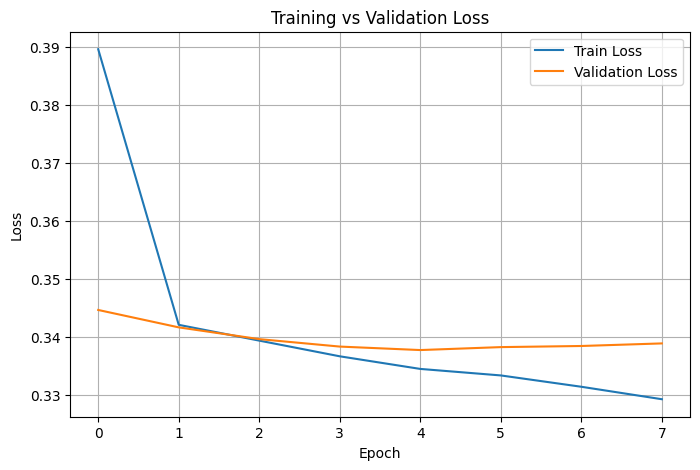

In [24]:
# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
import math

def recall_at_k(ranklist, ground_truth, k=10):
    ranklist_k = ranklist[:k]
    hits = len(set(ranklist_k) & set(ground_truth))
    return hits / len(ground_truth) if len(ground_truth) > 0 else 0.0

def ndcg_at_k(ranklist, ground_truth, k=10):
    ranklist_k = ranklist[:k]
    dcg = 0.0
    for idx, item in enumerate(ranklist_k):
        if item in ground_truth:
            dcg += 1.0 / math.log2(idx + 2)

    ideal_hits = min(len(ground_truth), k)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0

def full_ranking_evaluation(model, eval_df, all_user_positives, num_items, device, k=10):
    model.eval()

    user_targets = eval_df.groupby('userId')['movieId'].apply(set).to_dict()
    recalls = []
    ndcgs = []

    with torch.no_grad():
        for user, target_items in user_targets.items():
            # Exclude all known positives except the target items in this evaluation split
            excluded_items = all_user_positives[user] - target_items
            candidate_items = list(set(range(num_items)) - excluded_items)

            user_tensor = torch.tensor([user] * len(candidate_items), dtype=torch.long).to(device)
            item_tensor = torch.tensor(candidate_items, dtype=torch.long).to(device)

            scores = model(user_tensor, item_tensor).squeeze().cpu().numpy()

            item_score_pairs = list(zip(candidate_items, scores))
            item_score_pairs.sort(key=lambda x: x[1], reverse=True)

            ranked_items = [item for item, _ in item_score_pairs[:k]]

            recalls.append(recall_at_k(ranked_items, target_items, k))
            ndcgs.append(ndcg_at_k(ranked_items, target_items, k))

    return {
        f"Recall@{k}": float(np.mean(recalls)),
        f"NDCG@{k}": float(np.mean(ndcgs))
    }


In [26]:
# Evaluate base model
val_metrics = full_ranking_evaluation(
    model=base_model,
    eval_df=val,
    all_user_positives=all_user_positives,
    num_items=num_items,
    device=device,
    k=10
)

test_metrics = full_ranking_evaluation(
    model=base_model,
    eval_df=test,
    all_user_positives=all_user_positives,
    num_items=num_items,
    device=device,
    k=10
)

print("Validation Metrics:", val_metrics)
print("Test Metrics:", test_metrics)


Validation Metrics: {'Recall@10': 0.08391877644469203, 'NDCG@10': 0.12778568643226432}
Test Metrics: {'Recall@10': 0.08681689492339965, 'NDCG@10': 0.1308960818304923}


In [27]:
# Configurable NCF for comparison experiments
class FlexibleNCF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=32, mlp_layers=[64, 32, 16, 8]):
        super(FlexibleNCF, self).__init__()

        self.embed_user_GMF = nn.Embedding(num_users, embed_dim)
        self.embed_item_GMF = nn.Embedding(num_items, embed_dim)

        self.embed_user_MLP = nn.Embedding(num_users, embed_dim)
        self.embed_item_MLP = nn.Embedding(num_items, embed_dim)

        layers = []
        input_dim = embed_dim * 2

        # Use every layer declared in mlp_layers
        for hidden_dim in mlp_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim

        self.mlp_layers = nn.Sequential(*layers)
        mlp_output_dim = mlp_layers[-1]

        self.prediction = nn.Linear(embed_dim + mlp_output_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, u, i):
        gmf_user = self.embed_user_GMF(u)
        gmf_item = self.embed_item_GMF(i)
        gmf = gmf_user * gmf_item

        mlp_user = self.embed_user_MLP(u)
        mlp_item = self.embed_item_MLP(i)
        mlp_input = torch.cat([mlp_user, mlp_item], dim=-1)
        mlp_output = self.mlp_layers(mlp_input)

        combined = torch.cat([gmf, mlp_output], dim=-1)
        out = self.prediction(combined)
        return self.sigmoid(out)


In [28]:
def run_experiment(config, train_df, val_df, test_df, all_user_positives, all_items, num_users, num_items, device):
    print("\nRunning config:", config)

    model = FlexibleNCF(
        num_users=num_users,
        num_items=num_items,
        embed_dim=config['embed_dim'],
        mlp_layers=config['mlp_layers']
    ).to(device)

    model, history = fit_model(
        model=model,
        train_df=train_df,
        val_df=val_df,
        all_user_positives=all_user_positives,
        all_items=all_items,
        neg_ratio=config['neg_ratio'],
        batch_size=config['batch_size'],
        lr=config['lr'],
        epochs=config['epochs'],
        patience=config['patience'],
        device=device
    )

    val_metrics = full_ranking_evaluation(
        model=model,
        eval_df=val_df,
        all_user_positives=all_user_positives,
        num_items=num_items,
        device=device,
        k=10
    )

    test_metrics = full_ranking_evaluation(
        model=model,
        eval_df=test_df,
        all_user_positives=all_user_positives,
        num_items=num_items,
        device=device,
        k=10
    )

    result = {
        'embed_dim': config['embed_dim'],
        'mlp_layers': str(config['mlp_layers']),
        'neg_ratio': config['neg_ratio'],
        'batch_size': config['batch_size'],
        'lr': config['lr'],
        'val_recall@10': val_metrics['Recall@10'],
        'val_ndcg@10': val_metrics['NDCG@10'],
        'test_recall@10': test_metrics['Recall@10'],
        'test_ndcg@10': test_metrics['NDCG@10']
    }

    return result, history, model


In [29]:
# Comparison settings
configs = [
    {
        'embed_dim': 16,
        'mlp_layers': [32, 16, 8],
        'neg_ratio': 4,
        'batch_size': 1024,
        'lr': 0.001,
        'epochs': 8,
        'patience': 3
    },
    {
        'embed_dim': 32,
        'mlp_layers': [64, 32, 16, 8],
        'neg_ratio': 4,
        'batch_size': 1024,
        'lr': 0.001,
        'epochs': 8,
        'patience': 3
    },
    {
        'embed_dim': 32,
        'mlp_layers': [64, 32, 16, 8],
        'neg_ratio': 2,
        'batch_size': 1024,
        'lr': 0.001,
        'epochs': 8,
        'patience': 3
    },
    {
        'embed_dim': 64,
        'mlp_layers': [128, 64, 32, 16],
        'neg_ratio': 4,
        'batch_size': 1024,
        'lr': 0.001,
        'epochs': 8,
        'patience': 3
    }
]

all_results = []
all_histories = []
all_models = []

for cfg in configs:
    result, exp_history, trained_model = run_experiment(
        config=cfg,
        train_df=train,
        val_df=val,
        test_df=test,
        all_user_positives=all_user_positives,
        all_items=all_items,
        num_users=num_users,
        num_items=num_items,
        device=device
    )
    all_results.append(result)
    all_histories.append(exp_history)
    all_models.append(trained_model)

results_df = pd.DataFrame(all_results).sort_values(by='test_ndcg@10', ascending=False).reset_index(drop=True)
results_df



Running config: {'embed_dim': 16, 'mlp_layers': [32, 16, 8], 'neg_ratio': 4, 'batch_size': 1024, 'lr': 0.001, 'epochs': 8, 'patience': 3}
Positives : 86,292
Negatives : 345,168
Total     : 431,460
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 01 | Train Loss: 0.3993 | Val Loss: 0.3466
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 02 | Train Loss: 0.3435 | Val Loss: 0.3433
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 03 | Train Loss: 0.3416 | Val Loss: 0.3416
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 04 | Train Loss: 0.3393 | Val Loss: 0.3402
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 05 | Train Loss: 0.3370 | Val Loss: 0.3393
  -> Best model updated
Positives : 402,696
Negatives : 1,610,784
Total     : 2,013,480
Epoch 06 | Train Loss: 0.3358 | Val Loss: 0.3387
  ->

,embed_dim,mlp_layers,neg_ratio,batch_size,lr,val_recall@10,val_ndcg@10,test_recall@10,test_ndcg@10
0,64,"[128, 64, 32, 16]",4,1024,0.001,0.080962,0.129397,0.086156,0.134245
1,32,"[64, 32, 16, 8]",2,1024,0.001,0.081446,0.126229,0.085858,0.130802
2,32,"[64, 32, 16, 8]",4,1024,0.001,0.081876,0.125930,0.084436,0.130303
3,16,"[32, 16, 8]",4,1024,0.001,0.083984,0.126880,0.086006,0.127962


In [31]:
# Save best model from comparison
best_idx = results_df['test_ndcg@10'].idxmax()
best_model = all_models[best_idx]

print("Best experiment:")
print(results_df.loc[best_idx])

torch.save(best_model.state_dict(), "best_ncf_model.pth")
print("Saved as best_ncf_model.pth")


Best experiment:
embed_dim                        64
mlp_layers        [128, 64, 32, 16]
neg_ratio                         4
batch_size                     1024
lr                            0.001
val_recall@10              0.080962
val_ndcg@10                0.129397
test_recall@10             0.086156
test_ndcg@10               0.134245
Name: 0, dtype: object
Saved as best_ncf_model.pth
